## 1-Install and Imports

In [2]:
!pip install -q ultralytics kagglehub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 21.1 MB/s eta 0:00:00a 0:00:01


In [3]:
import os, shutil, json, time, glob
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import yaml
import torch
from ultralytics import YOLO

# Dark theme
plt.rcParams.update({
    'figure.facecolor':'#0f0f1a','axes.facecolor':'#1a1a2e',
    'axes.edgecolor':'#333355','axes.labelcolor':'#e0e0ff',
    'xtick.color':'#a0a0cc','ytick.color':'#a0a0cc',
    'text.color':'#e0e0ff','grid.color':'#2a2a4a',
    'grid.linestyle':'--','grid.alpha':0.5,'font.family':'monospace',
})

# Palette
NEON,ORANGE,BLUE,PURPLE,YELLOW,BG,PANEL = (
    '#00f5d4','#ff6b35','#4cc9f0','#a855f7','#ffd60a','#0f0f1a','#1a1a2e')

print(f"PyTorch : {torch.__version__}")
print(f"GPU     : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")
print("✅ Ready")


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
PyTorch : 2.10.0+cu128
GPU     : Tesla T4
✅ Ready


## 2-Download & Fix BDD100K Dataset

In [4]:
import kagglehub

DATASET_PATH = kagglehub.dataset_download("a7madmostafa/bdd100k-yolo")
print("Dataset path :", DATASET_PATH)

# Fix chemins dans data.yaml
with open(f"{DATASET_PATH}/data.yaml") as f:
    content = f.read()
content = content.replace('/kaggle/input/bdd100k-yolo', DATASET_PATH)

DATASET_YAML = "/tmp/data_fixed.yaml"
with open(DATASET_YAML, 'w') as f:
    f.write(content)

with open(DATASET_YAML) as f:
    CFG = yaml.safe_load(f)

print(f"nc     : {CFG['nc']}")
print(f"names  : {CFG['names']}")
print("✅ YAML fixed")


Dataset path : /kaggle/input/datasets/a7madmostafa/bdd100k-yolo
nc     : 10
names  : ['person', 'rider', 'car', 'bus', 'truck', 'bike', 'motor', 'traffic light', 'traffic sign', 'train']
✅ YAML fixed


## 3-Dataset Validation

In [5]:
def resolve(rel):
    p = Path(rel)
    return p if p.is_absolute() else Path(DATASET_PATH) / rel

# Check splits
for split in ['train', 'val']:
    img_dir = resolve(CFG.get(split, f'images/{split}'))
    lbl_dir = Path(str(img_dir).replace('images', 'labels'))
    imgs = len(list(img_dir.glob('*.jpg')) + list(img_dir.glob('*.png')))
    lbls = len(list(lbl_dir.glob('*.txt'))) if lbl_dir.exists() else 0
    ok = '✅' if imgs and lbls else '❌'
    print(f"{ok} {split:5s}: {imgs:6,} images  {lbls:6,} labels")

# Class distribution (500 sample files — fast)
train_img_dir = resolve(CFG.get('train', 'images/train'))
train_lbl_dir = Path(str(train_img_dir).replace('images', 'labels'))
ids = []
for lf in sorted(train_lbl_dir.glob('*.txt'))[:500]:
    for line in lf.read_text().splitlines():
        parts = line.strip().split()
        if parts: ids.append(int(parts[0]))

cnt = Counter(ids)
print("\nClass distribution (500-file sample):")
for cid in sorted(cnt):
    name = CFG['names'][cid] if cid < len(CFG['names']) else f'UNKNOWN({cid})'
    bar  = '█' * min(cnt[cid]//15, 40)
    print(f"  [{cid:2d}] {name:<20} {cnt[cid]:5d}  {bar}")

bad_ids = [cid for cid in cnt if cid >= CFG['nc']]
if bad_ids:
    print(f"\n⚠️  Label IDs {bad_ids} >= nc={CFG['nc']} — vérifier data.yaml !")
else:
    print(f"\n✅ Cohérence nc/labels OK")


✅ train: 70,000 images  70,000 labels
✅ val  : 10,000 images  10,000 labels

Class distribution (500-file sample):
  [ 0] person                 568  █████████████████████████████████████
  [ 1] rider                   25  █
  [ 2] car                   4955  ████████████████████████████████████████
  [ 3] bus                     89  █████
  [ 4] truck                  220  ██████████████
  [ 5] bike                    53  ███
  [ 6] motor                   13  
  [ 7] traffic light         1336  ████████████████████████████████████████
  [ 8] traffic sign          1722  ████████████████████████████████████████
  [ 9] train                    1  

✅ Cohérence nc/labels OK


## 4-Configuration

In [6]:
# ── Modèle ───────────────────────────────────────────────────────────────────
PRETRAINED_MODEL = 'yolo11n.pt'   # nano = le plus rapide sur Kaggle

# ── Hyper-paramètres ─────────────────────────────────────────────────────────
EPOCHS      = 10    
IMG_SIZE    = 640
BATCH_SIZE  = 16    # réduire à 8 si OOM
LR0         = 0.01
LRF         = 0.001
PATIENCE    = 10    # early stopping
WORKERS     = 2

# ── Nommage du run ────────────────────────────────────────────────────────────
PROJECT_NAME = 'traffic_yolo11'
RUN_NAME     = 'bdd100k_v1'

# ── Sorties ───────────────────────────────────────────────────────────────────
OUTPUT_DIR = Path('/kaggle/working/outputs')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
DEVICE    = 0 if torch.cuda.is_available() else 'cpu'
TIMESTAMP = time.strftime('%Y%m%d_%H%M%S')

# ── Sanity check ──────────────────────────────────────────────────────────────
assert Path(DATASET_YAML).exists()
print(f"✅ Config OK  |  device={DEVICE}  |  model={PRETRAINED_MODEL}")
print(f"   {EPOCHS} epochs  ·  bs={BATCH_SIZE}  ·  {CFG['nc']} classes")


✅ Config OK  |  device=0  |  model=yolo11n.pt
   10 epochs  ·  bs=16  ·  10 classes


## 5-Fine-Tune YOLOv11

In [7]:
model = YOLO(PRETRAINED_MODEL)
print(f"Params : {sum(p.numel() for p in model.model.parameters()):,}")

results = model.train(
    data=DATASET_YAML, pretrained=True,
    epochs=EPOCHS, imgsz=IMG_SIZE, batch=BATCH_SIZE,
    device=DEVICE, workers=WORKERS, patience=PATIENCE,
    optimizer='AdamW', lr0=LR0, lrf=LRF,
    cos_lr=True, warmup_epochs=3, weight_decay=0.0005,
    mosaic=1.0, mixup=0.15, copy_paste=0.1,
    degrees=10.0, translate=0.1, scale=0.5,
    fliplr=0.5, flipud=0.0,
    hsv_h=0.015, hsv_s=0.7, hsv_v=0.4,
    label_smoothing=0.1,
    save=True, save_period=5,
    project=PROJECT_NAME, name=RUN_NAME,
    exist_ok=True, verbose=True,
)
print("\n✅ Training complete!")


Params : 2,624,080
WARNING ⚠️ 'label_smoothing' is deprecated and will be removed in the future.
Ultralytics 8.4.42 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.1, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/tmp/data_fixed.yaml, degrees=10.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.001, mask_ratio=4, max_det=300, mixup=0.15, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=bdd100k_v1, nbs=

## 6-Save - Weights

In [13]:
from pathlib import Path
import shutil

TRAIN_DIR = Path("/kaggle/working/runs/detect/traffic_yolo11/bdd100k_v1")
WEIGHTS_DIR = TRAIN_DIR / "weights"

best_pt = WEIGHTS_DIR / "best.pt"
last_pt = WEIGHTS_DIR / "last.pt"

assert best_pt.exists(), "best.pt not found"
assert last_pt.exists(), "last.pt not found"

save_best = OUTPUT_DIR / f"yolo11_best_{TIMESTAMP}.pt"
save_last = OUTPUT_DIR / f"yolo11_last_{TIMESTAMP}.pt"

shutil.copy(best_pt, save_best)
shutil.copy(last_pt, save_last)

print("best.pt →", save_best)
print("last.pt →", save_last)

best.pt → /kaggle/working/outputs/yolo11_best_20260428_112223.pt
last.pt → /kaggle/working/outputs/yolo11_last_20260428_112223.pt


## 7-Training Dashboard

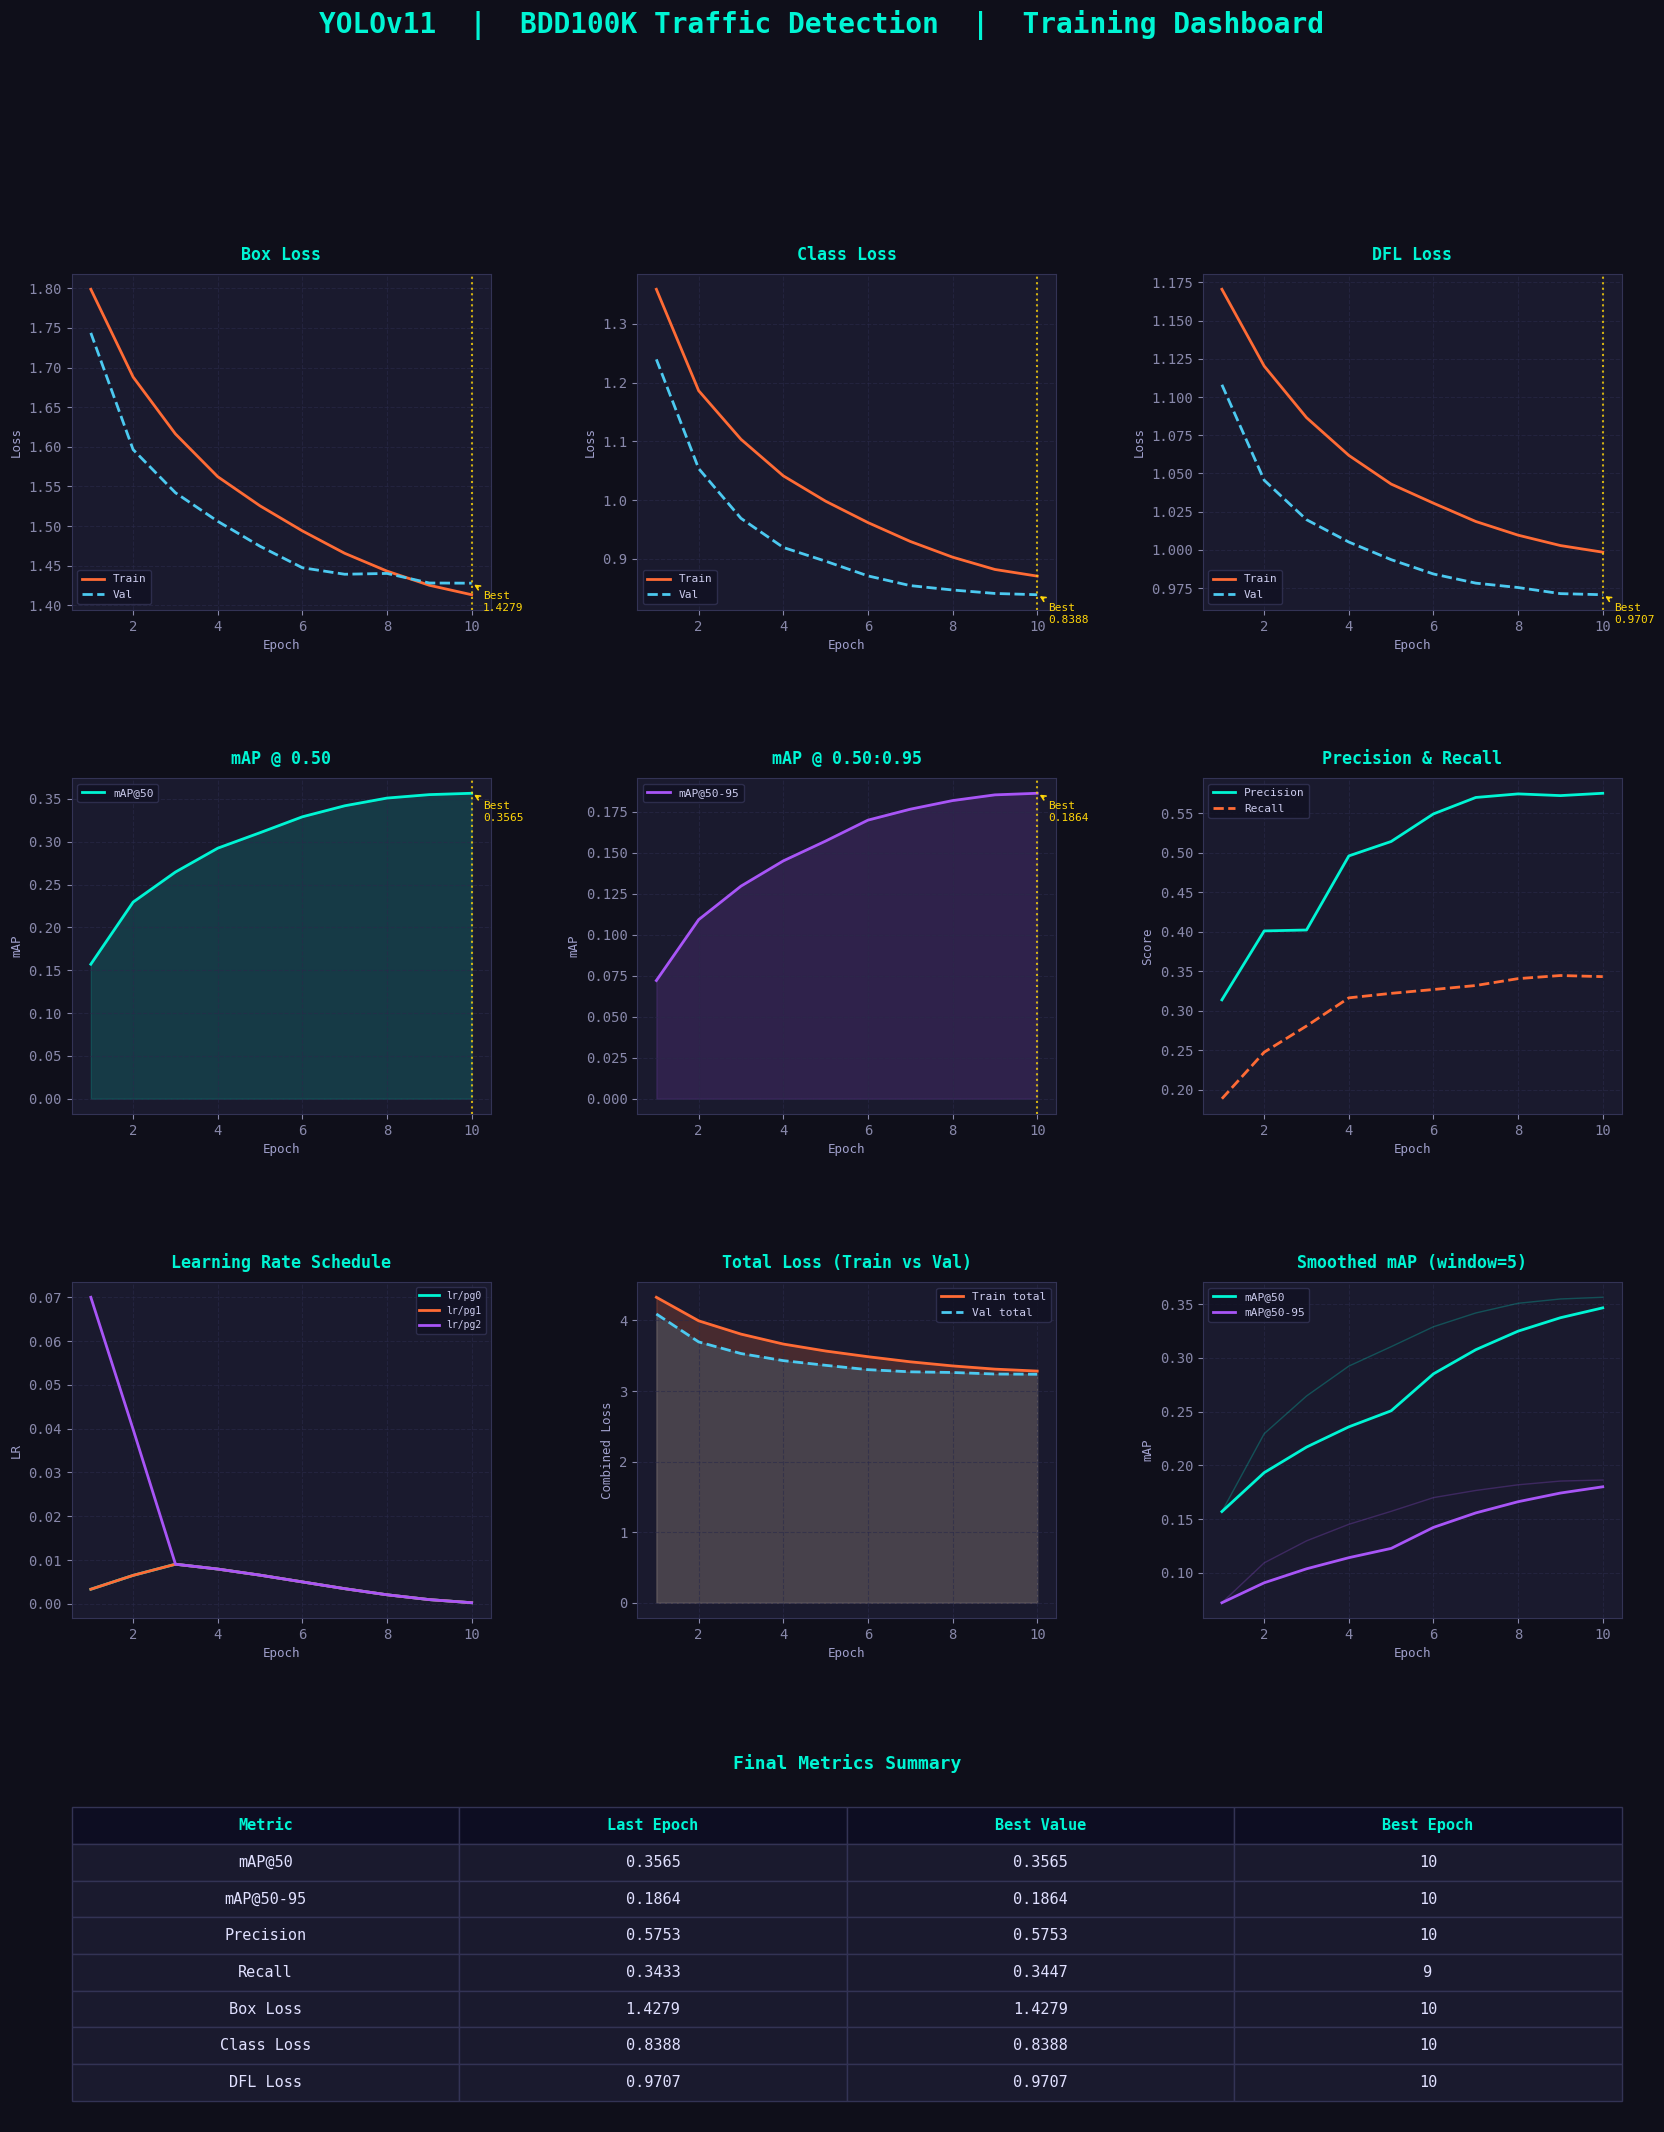

✅ Training dashboard saved


In [14]:
df = pd.read_csv(TRAIN_DIR / 'results.csv')
df.columns = df.columns.str.strip()
ep = df['epoch']

def sax(ax, title, ylabel=None):
    ax.set_facecolor(PANEL); ax.set_title(title, color=NEON, fontsize=12, fontweight='bold', pad=10)
    ax.set_xlabel('Epoch', color='#a0a0cc', fontsize=9)
    if ylabel: ax.set_ylabel(ylabel, color='#a0a0cc', fontsize=9)
    ax.grid(True, color='#2a2a4a', linestyle='--', alpha=0.6)
    ax.spines[:].set_color('#333355'); ax.tick_params(colors='#8888aa')

def splot(ax, col, color, label, ls='-', fill=False):
    if col not in df.columns: return
    y = df[col]
    ax.plot(ep, y, color=color, lw=2, label=label, linestyle=ls)
    if fill: ax.fill_between(ep, y, alpha=0.15, color=color)
    ax.legend(fontsize=8, labelcolor='#ccccee', facecolor='#111122', edgecolor='#333355')

def mark(ax, col, mode='max'):
    if col not in df.columns: return
    idx = df[col].idxmax() if mode=='max' else df[col].idxmin()
    e, v = df.loc[idx,'epoch'], df.loc[idx,col]
    ax.axvline(e, color=YELLOW, ls=':', alpha=0.8, lw=1.5)
    ax.annotate(f'Best\n{v:.4f}', xy=(e,v), xytext=(8,-20), textcoords='offset points',
                color=YELLOW, fontsize=8, arrowprops=dict(arrowstyle='->', color=YELLOW, lw=1.2))

fig = plt.figure(figsize=(20,24), facecolor=BG)
fig.suptitle('YOLOv11  |  BDD100K Traffic Detection  |  Training Dashboard',
             fontsize=20, fontweight='bold', color=NEON, y=0.99)
gs = gridspec.GridSpec(4,3,figure=fig,hspace=0.50,wspace=0.35)

# Row 0 — Losses
for i,(title,tr,vl) in enumerate([
    ('Box Loss',   'train/box_loss','val/box_loss'),
    ('Class Loss', 'train/cls_loss','val/cls_loss'),
    ('DFL Loss',   'train/dfl_loss','val/dfl_loss'),
]):
    ax = fig.add_subplot(gs[0,i]); sax(ax,title,'Loss')
    splot(ax,tr,ORANGE,'Train'); splot(ax,vl,BLUE,'Val',ls='--'); mark(ax,vl,'min')

# Row 1 — mAP + PR
ax=fig.add_subplot(gs[1,0]); sax(ax,'mAP @ 0.50','mAP')
splot(ax,'metrics/mAP50(B)',NEON,'mAP@50',fill=True); mark(ax,'metrics/mAP50(B)')

ax=fig.add_subplot(gs[1,1]); sax(ax,'mAP @ 0.50:0.95','mAP')
splot(ax,'metrics/mAP50-95(B)',PURPLE,'mAP@50-95',fill=True); mark(ax,'metrics/mAP50-95(B)')

ax=fig.add_subplot(gs[1,2]); sax(ax,'Precision & Recall','Score')
splot(ax,'metrics/precision(B)',NEON,'Precision')
splot(ax,'metrics/recall(B)',ORANGE,'Recall',ls='--')

# Row 2 — LR + Total loss + Smoothed mAP
ax=fig.add_subplot(gs[2,0]); sax(ax,'Learning Rate Schedule','LR')
for col,col_c in zip([c for c in df.columns if 'lr' in c.lower()][:3],[NEON,ORANGE,PURPLE]):
    ax.plot(ep,df[col],color=col_c,lw=2,label=col)
ax.legend(fontsize=7,labelcolor='#ccccee',facecolor='#111122',edgecolor='#333355')

ax=fig.add_subplot(gs[2,1]); sax(ax,'Total Loss (Train vs Val)','Combined Loss')
tl=[c for c in df.columns if 'train' in c and 'loss' in c]
vl=[c for c in df.columns if 'val'   in c and 'loss' in c]
if tl:
    s=df[tl].sum(1); ax.fill_between(ep,s,alpha=0.2,color=ORANGE)
    ax.plot(ep,s,color=ORANGE,lw=2,label='Train total')
if vl:
    s=df[vl].sum(1); ax.fill_between(ep,s,alpha=0.15,color=BLUE)
    ax.plot(ep,s,color=BLUE,lw=2,ls='--',label='Val total')
ax.legend(fontsize=8,labelcolor='#ccccee',facecolor='#111122',edgecolor='#333355')

ax=fig.add_subplot(gs[2,2]); sax(ax,'Smoothed mAP (window=5)','mAP')
for col,col_c,lbl in [('metrics/mAP50(B)',NEON,'mAP@50'),('metrics/mAP50-95(B)',PURPLE,'mAP@50-95')]:
    if col in df.columns:
        sm=df[col].rolling(5,min_periods=1).mean()
        ax.plot(ep,df[col],color=col_c,alpha=0.25,lw=1)
        ax.plot(ep,sm,color=col_c,lw=2,label=lbl)
ax.legend(fontsize=8,labelcolor='#ccccee',facecolor='#111122',edgecolor='#333355')

# Row 3 — Summary table
ax=fig.add_subplot(gs[3,:]); ax.set_facecolor(PANEL); ax.axis('off')
ax.set_title('Final Metrics Summary',color=NEON,fontsize=13,fontweight='bold',pad=12)
MMAP={
    'mAP@50':('metrics/mAP50(B)','max'),'mAP@50-95':('metrics/mAP50-95(B)','max'),
    'Precision':('metrics/precision(B)','max'),'Recall':('metrics/recall(B)','max'),
    'Box Loss':('val/box_loss','min'),'Class Loss':('val/cls_loss','min'),'DFL Loss':('val/dfl_loss','min'),
}
rows=[]
for lbl,(col,mode) in MMAP.items():
    if col in df.columns:
        last=df[col].iloc[-1]; best=df[col].max() if mode=='max' else df[col].min()
        bidx=df[col].idxmax() if mode=='max' else df[col].idxmin()
        rows.append([lbl,f'{last:.4f}',f'{best:.4f}',f"{df.loc[bidx,'epoch']:.0f}"])
if rows:
    tbl=ax.table(cellText=rows,colLabels=['Metric','Last Epoch','Best Value','Best Epoch'],
                 loc='center',cellLoc='center')
    tbl.auto_set_font_size(False); tbl.set_fontsize(11); tbl.scale(1.0,2.2)
    for (r,c),cell in tbl.get_celld().items():
        cell.set_edgecolor('#333355')
        if r==0: cell.set_facecolor('#0d0d22'); cell.set_text_props(color=NEON,fontweight='bold')
        else: cell.set_facecolor('#1a1a2e'); cell.set_text_props(color='#e0e0ff')

plt.savefig(OUTPUT_DIR/f'training_dashboard_{TIMESTAMP}.png',dpi=150,bbox_inches='tight',facecolor=BG)
plt.show()
print("Training dashboard saved")


## 8-Validation + Confusion Matrix + Per-Class Metrics

Ultralytics 8.4.42 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,584,102 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 109.3±49.1 MB/s, size: 54.7 KB)
val: Scanning /kaggle/input/datasets/a7madmostafa/bdd100k-yolo/val/labels... 10000 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 10000/10000 767.9it/s 13.0s.1s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/a7madmostafa/bdd100k-yolo/val is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 625/625 8.7it/s 1:12<0.1ss
                   all      10000     185578      0.577      0.344      0.357      0.187
Speed: 0.5ms preprocess, 2.1ms inference, 0.0ms loss, 1.0ms postprocess per image
Results saved to /kaggle/working/runs/detect/val
mAP@50    : 0.3571
mAP@50-95 : 0.1867
Precision : 0.5766
Recall    : 0.3437


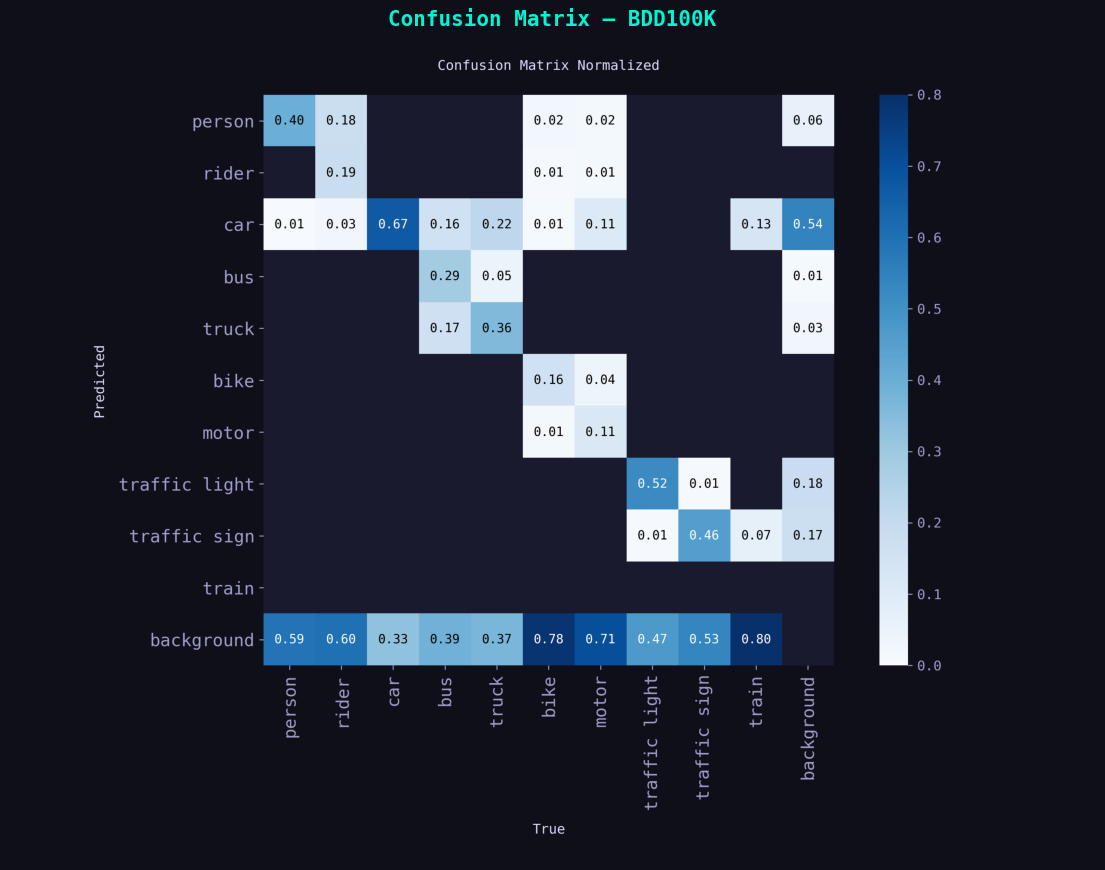

/tmp/ipykernel_55/1616121942.py:111: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(class_names, rotation=35, ha="right", fontsize=8)
/tmp/ipykernel_55/1616121942.py:111: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(class_names, rotation=35, ha="right", fontsize=8)


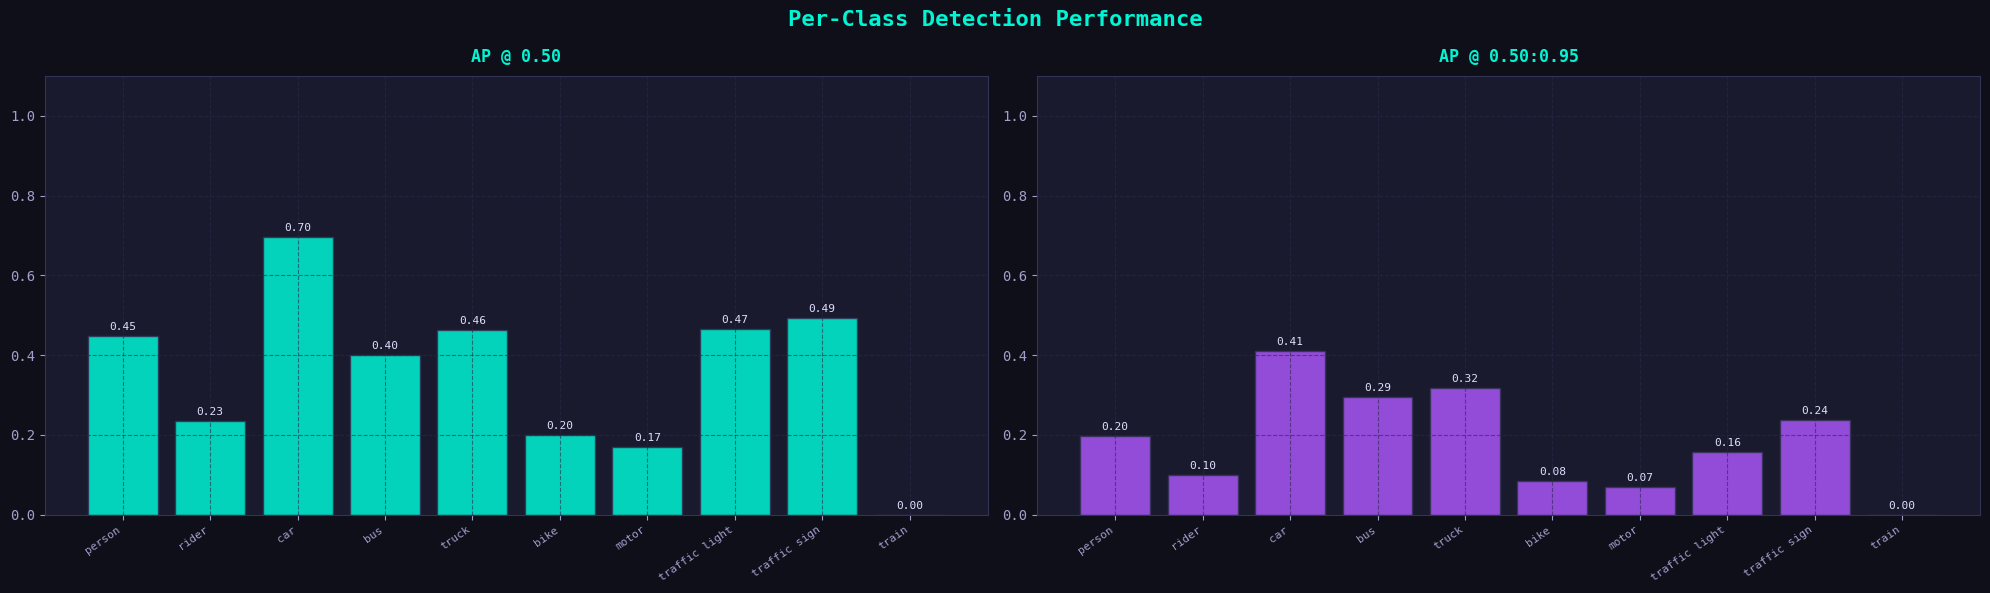


Class                     AP@50   AP@50:95
--------------------------------------------
✅ person                 0.4488     0.1965
✅ rider                  0.2344     0.0991
✅ car                    0.6957     0.4111
✅ bus                    0.4013     0.2944
✅ truck                  0.4638     0.3175
✅ bike                   0.1990     0.0850
✅ motor                  0.1697     0.0704
✅ traffic light          0.4665     0.1567
✅ traffic sign           0.4921     0.2368
❌ train                  0.0000     0.0000

⚠️ Low-performing classes (AP@50 < 0.05): ['train']
→ Check dataset balance + labeling consistency


In [16]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# ─────────────────────────────
# LOAD MODEL (SAFE)
# ─────────────────────────────
best_model = YOLO(str(best_pt))

# ─────────────────────────────
# VALIDATION
# ─────────────────────────────
val_results = best_model.val(
    data=DATASET_YAML,
    imgsz=IMG_SIZE,
    batch=BATCH_SIZE,
    device=DEVICE,
    workers=WORKERS,
    verbose=False,
)

print(f"mAP@50    : {val_results.box.map50:.4f}")
print(f"mAP@50-95 : {val_results.box.map:.4f}")
print(f"Precision : {val_results.box.mp:.4f}")
print(f"Recall    : {val_results.box.mr:.4f}")

# ─────────────────────────────
# CONFUSION MATRIX (SAFE PATH SEARCH)
# ─────────────────────────────
cm_path = None
for name in ["confusion_matrix_normalized.png", "confusion_matrix.png"]:
    p = Path(TRAIN_DIR) / name
    if p.exists():
        cm_path = p
        break

if cm_path:
    fig, ax = plt.subplots(figsize=(14, 12), facecolor=BG)
    ax.set_facecolor(BG)
    ax.imshow(plt.imread(str(cm_path)))
    ax.axis("off")
    ax.set_title(
        "Confusion Matrix — BDD100K",
        color=NEON,
        fontsize=15,
        fontweight="bold",
        pad=15
    )

    plt.savefig(
        OUTPUT_DIR / f"confusion_matrix_{TIMESTAMP}.png",
        dpi=150,
        bbox_inches="tight",
        facecolor=BG
    )
    plt.show()
else:
    print("Confusion matrix not found")

# ─────────────────────────────
# PER CLASS METRICS (SAFE)
# ─────────────────────────────
class_names = CFG["names"]

ap50_per_cls = np.array(val_results.box.ap50)
map_per_cls  = np.array(val_results.box.maps)

# safety fix (length mismatch guard)
n = min(len(class_names), len(ap50_per_cls), len(map_per_cls))
class_names = class_names[:n]
ap50_per_cls = ap50_per_cls[:n]
map_per_cls = map_per_cls[:n]

# ─────────────────────────────
# PLOT
# ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(20, 6), facecolor=BG)
fig.suptitle(
    "Per-Class Detection Performance",
    color=NEON,
    fontsize=16,
    fontweight="bold"
)

plots = [
    (ap50_per_cls, "AP @ 0.50", NEON),
    (map_per_cls, "AP @ 0.50:0.95", PURPLE)
]

for ax, (vals, title, color) in zip(axes, plots):
    ax.set_facecolor(PANEL)
    ax.set_title(title, color=NEON, fontsize=12, fontweight="bold", pad=10)

    ax.grid(True, color="#2a2a4a", ls="--", alpha=0.6)
    ax.spines[:].set_color("#333355")

    bars = ax.bar(class_names, vals, color=color, alpha=0.85, edgecolor="#333355")

    for bar, v in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.01,
            f"{v:.2f}",
            ha="center",
            va="bottom",
            color="#e0e0ff",
            fontsize=8
        )

    ax.set_xticklabels(class_names, rotation=35, ha="right", fontsize=8)
    ax.set_ylim(0, 1.1)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / f"per_class_ap_{TIMESTAMP}.png",
    dpi=150,
    bbox_inches="tight",
    facecolor=BG
)

plt.show()

# ─────────────────────────────
# SUMMARY
# ─────────────────────────────
print(f"\n{'Class':<22} {'AP@50':>8} {'AP@50:95':>10}")
print("-" * 44)

missing = []

for name, a50, a95 in zip(class_names, ap50_per_cls, map_per_cls):
    ok = "✅" if a50 > 0.05 else "❌"
    print(f"{ok} {name:<20} {a50:>8.4f} {a95:>10.4f}")

    if a50 < 0.05:
        missing.append(name)

# ─────────────────────────────
# ALERT
# ─────────────────────────────
if missing:
    print(f"\nLow-performing classes (AP@50 < 0.05): {missing}")
    print("→ Check dataset balance + labeling consistency")
else:
    print("\n✅ All classes are reasonably detected.")